In [28]:
import numpy as np
from scipy.special import airy, airye
from funcs import load_matrices, matrix_funcs
from scipy.integrate import quad
import matplotlib.pyplot as plt
from scipy.special import airy, airye, riccati_jn, riccati_yn, iv, kv
from scipy.interpolate import CubicSpline


def riccati_in(n, x):
    f = np.array([np.sqrt(x)*iv(l+(1./2), x) for l in range(n+1)])
    fp = np.array([(x*(iv(l-(1./2), x)+iv(l+(3./2), x))+iv(l+(1./2), x))/(2*np.sqrt(x)) for l in range(n+1)])
    return f, fp


def riccati_kn(n, x):
    f = np.array([np.sqrt(x)*kv(l+(1./2), x) for l in range(n+1)])
    fp = np.array([(-x*(kv(l-(1./2), x)+kv(l+(3./2), x))+kv(l+(1./2), x))/(2*np.sqrt(x)) for l in range(n+1)])
    return f, fp


def airy_imb_prop(r, warr, wparr, n, bc='large'):
    k2 = np.zeros((len(warr), n))
    t = np.zeros((len(warr), n, n), dtype=complex)
    wpt = np.zeros((len(warr), n, n), dtype=complex)
    for i in range(len(warr)):
        k2[i], t[i] = np.linalg.eigh(warr[i])
        wpt[i] = np.matrix(t[i]).H @ (np.matrix(wparr[i]) @ np.matrix(t[i]))
    p = np.array([np.matrix(t[i]).H @ np.matrix(t[i-1]) if i > 0 else np.matrix(t[0]) for i in range(len(warr))])
    c1 = np.zeros((len(warr), n, n), dtype=complex)
    c2 = np.zeros((len(warr), n, n), dtype=complex)
    c3 = np.zeros((len(warr), n, n), dtype=complex)
    c4 = np.zeros((len(warr), n, n), dtype=complex)
    errors = np.zeros((len(warr), n), dtype=complex)
    for i in range(len(warr)):
        alpha = np.array([-(wpt[i,j,j])**(1./3.) if np.allclose(-(wpt[i,j,j])**(1./3.), np.real(-(wpt[i,j,j])**(1./3.)))
                          else -(wpt[i,j,j])**(1./3.)*np.exp(-1j*np.angle(-(wpt[i,j,j])**(1./3.))) for j in range(n)])
        beta = k2[i]/np.diag(wpt[i])
        rhob = np.diff(r)[i]/2
        x = np.array([[alpha[j]*(-rhob+beta[j]), alpha[j]*(rhob+beta[j])] for j in range(n)])
        for j in range(n):
            offdiag = np.max(np.abs(np.array([wpt[i, k, j] for k in range(n) if k != j])))/(wpt[i,j,j]**(2./3))
            if np.any(np.real(x[j]) > 100):
                dksi = np.diff((2./3)*(x[j]**(3./2)))[0]
                aie, aiep, bie, biep = airye(np.real(x[j]))
                c1[i,j,j] = np.pi*(np.exp(-dksi)*aie[1]*biep[0]-np.exp(dksi)*bie[1]*aiep[0])
                c2[i,j,j] = np.pi*(np.exp(dksi)*bie[1]*aie[0]-np.exp(-dksi)*aie[1]*bie[0])/alpha[j]
                c3[i,j,j] = np.pi*alpha[j]*(np.exp(-dksi)*aiep[1]*biep[0]-np.exp(dksi)*biep[1]*aiep[0])
                c4[i,j,j] = np.pi*(np.exp(dksi)*biep[1]*aie[0]-np.exp(-dksi)*aiep[1]*bie[0])
                err_int = quad(lambda xi: airye(xi)[0]*airye(xi)[2]*(xi+beta[j]), x[j,0], x[j,1], complex_func=True)[0]
                # print(airye[x[j,0]][0])
            else:
                ai, aip, bi, bip = airy(np.real(x[j]))
                c1[i,j,j] = np.pi*(ai[1]*bip[0]-bi[1]*aip[0]) #/wr[j]
                c2[i,j,j] = np.pi*(bi[1]*ai[0]-ai[1]*bi[0])/alpha[j]
                c3[i,j,j] = np.pi*alpha[j]*(aip[1]*bip[0]-bip[1]*aip[0]) #/wr[j]
                c4[i,j,j] = np.pi*(bip[1]*ai[0]-aip[1]*bi[0]) #/wr[j]
                err_int = quad(lambda xi: airy(xi)[0]*airy(xi)[2]*(xi+beta[j]), x[j,0], x[j,1], complex_func=True)[0]
            errors[i,j] = offdiag*err_int
    d1 = np.array([np.matrix(c2[i]).I @ c1[i] for i in range(len(warr))])
    d2 = np.array([np.matrix(c2[i]).I for i in range(len(warr))])
    d3 = np.array([c4[i] @ np.matrix(c2[i]).I @ c1[i] - c3[i] for i in range(len(warr))])
    d4 = np.array([c4[i] @ np.matrix(c2[i]).I for i in range(len(warr))])
    y = np.zeros((len(r), n, n), dtype=complex)
    if bc == 'large':
        y[0] = 1e308*np.eye(n, dtype=complex)
    else:
        for i in range(n):
            y[0,i,i] = -(np.sqrt(np.abs(wpt[0,i,i]))/(2*np.sqrt(np.abs(k2[0,i])))+np.sqrt(np.abs(k2[0,i])))
        y[0] = np.diag(np.sqrt(np.abs(k2[0])))
    dy = np.zeros((n,n), dtype=complex)
    for i in range(len(warr)):
        prey = d4[i] - d3[i] @ np.matrix(y[i]+d1[i]).I @ d2[i]
        y[i+1] = np.matrix(p[i]) @ (prey @ np.matrix(p[i]).H)
        dy = np.matrix(p[i]) @ ((dy + np.diag(errors[i])) @ np.matrix(p[i]).H)
    return np.matrix(t[-1]).H @ (y[-1] @ np.matrix(t[-1])), errors, dy


dir = 'H_1_p'
r, hls, ddrls = load_matrices(dir)
emin = hls[-1,0,0]
n = len(hls[0])
shift = np.array([emin*np.eye(len(hls[0]), dtype=complex)]*len(r))
vd = (hls-shift)/4.637
hfunc, ddrfunc = matrix_funcs(r, vd, ddrls)
emax = np.abs(np.array(hfunc(r[0])[-1,-1]))

egrid = np.arange(emax, -0.2, -0.2)
grid = [x for x in r]
for i in range(n):
    sp = CubicSpline(r, np.real(vd[:,i,i]))
    for e in egrid:
        roots = sp.solve(e)
        for x in roots:
            if x >= r[0] and x <= r[-1]:
                grid.append(x)
grid = np.unique(np.round(np.sort(np.array(grid)), decimals=4))

w = lambda rs, l, e: np.array([e*np.eye(n)-(hfunc(r)+l*(l*1)/(r**2)*np.eye(n)) for r in rs])
wp = lambda rs, l: np.array([-(hfunc(r,1)-2*l*(l*1)/(r**3)*np.eye(n)) for r in rs])
wp2 = lambda rs, l: np.array([-(hfunc(r,2)+6*l*(l*1)/(r**4)*np.eye(n)) for r in rs])

es = emax/4
print(es)
l = 5
y, errs, dy = airy_imb_prop(grid, w(grid[:-1]+np.diff(grid)/2, l, es), wp(grid[:-1]+np.diff(grid)/2, l), n, bc='qc')

jmat = np.zeros((n, n))
nmat = np.zeros((n, n))
jpmat = np.zeros((n, n))
npmat = np.zeros((n, n))
nt = np.sum(np.diag(vd[-1]) < es)
ks = np.sqrt(np.abs(np.diag(es*np.eye(n)-hfunc(r[-1]))))
for j in range(n):
    if j <= nt:
        prej, prejp = riccati_jn(l-1, np.real(ks[j])*r[-1])
        pren, prenp = riccati_yn(l-1, np.real(ks[j])*r[-1])
        jmat[j,j] = prej[-1]/np.sqrt(np.real(ks[j]))
        nmat[j,j] = pren[-1]/np.sqrt(np.real(ks[j]))
        jpmat[j,j] = np.sqrt(np.real(ks[j])) * prejp[-1]
        npmat[j,j] = np.sqrt(np.real(ks[j])) * prenp[-1]
    else:
        prej, prejp = riccati_in(l-1, np.real(ks[j])*r[-1])
        pren, prenp = riccati_kn(l-1, np.real(ks[j])*r[-1])
        jmat[j,j] = prej[-1]
        nmat[j,j] = pren[-1]
        jpmat[j,j] = ks[j] * prejp[-1]
        npmat[j,j] = ks[j] * prenp[-1]
rmat = -np.matrix(npmat - y @ nmat).I @ np.matrix(jpmat - y @ jmat)
drmat = -np.matrix(npmat - y @ nmat).I @ dy @ nmat @ np.matrix(npmat - y @ nmat).I @ dy @ jmat
smat = np.matrix(np.eye(nt) + 1j*rmat[:nt,:nt]).I @ np.matrix(np.eye(nt) - 1j*rmat[:nt,:nt])
dsmat = -np.matrix(np.eye(nt) + 1j*rmat[:nt,:nt]).I @ drmat[:nt,:nt] @ np.matrix(np.eye(nt) + 1j*rmat[:nt,:nt]).I @ drmat[:nt,:nt]

428.7319387535042


/tmp/ipykernel_26816/144982359.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['']+p1_labels)
/tmp/ipykernel_26816/144982359.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['']+p1_labels)
/tmp/ipykernel_26816/144982359.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['']+p1_labels)
/tmp/ipykernel_26816/144982359.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['']+p1_labels)


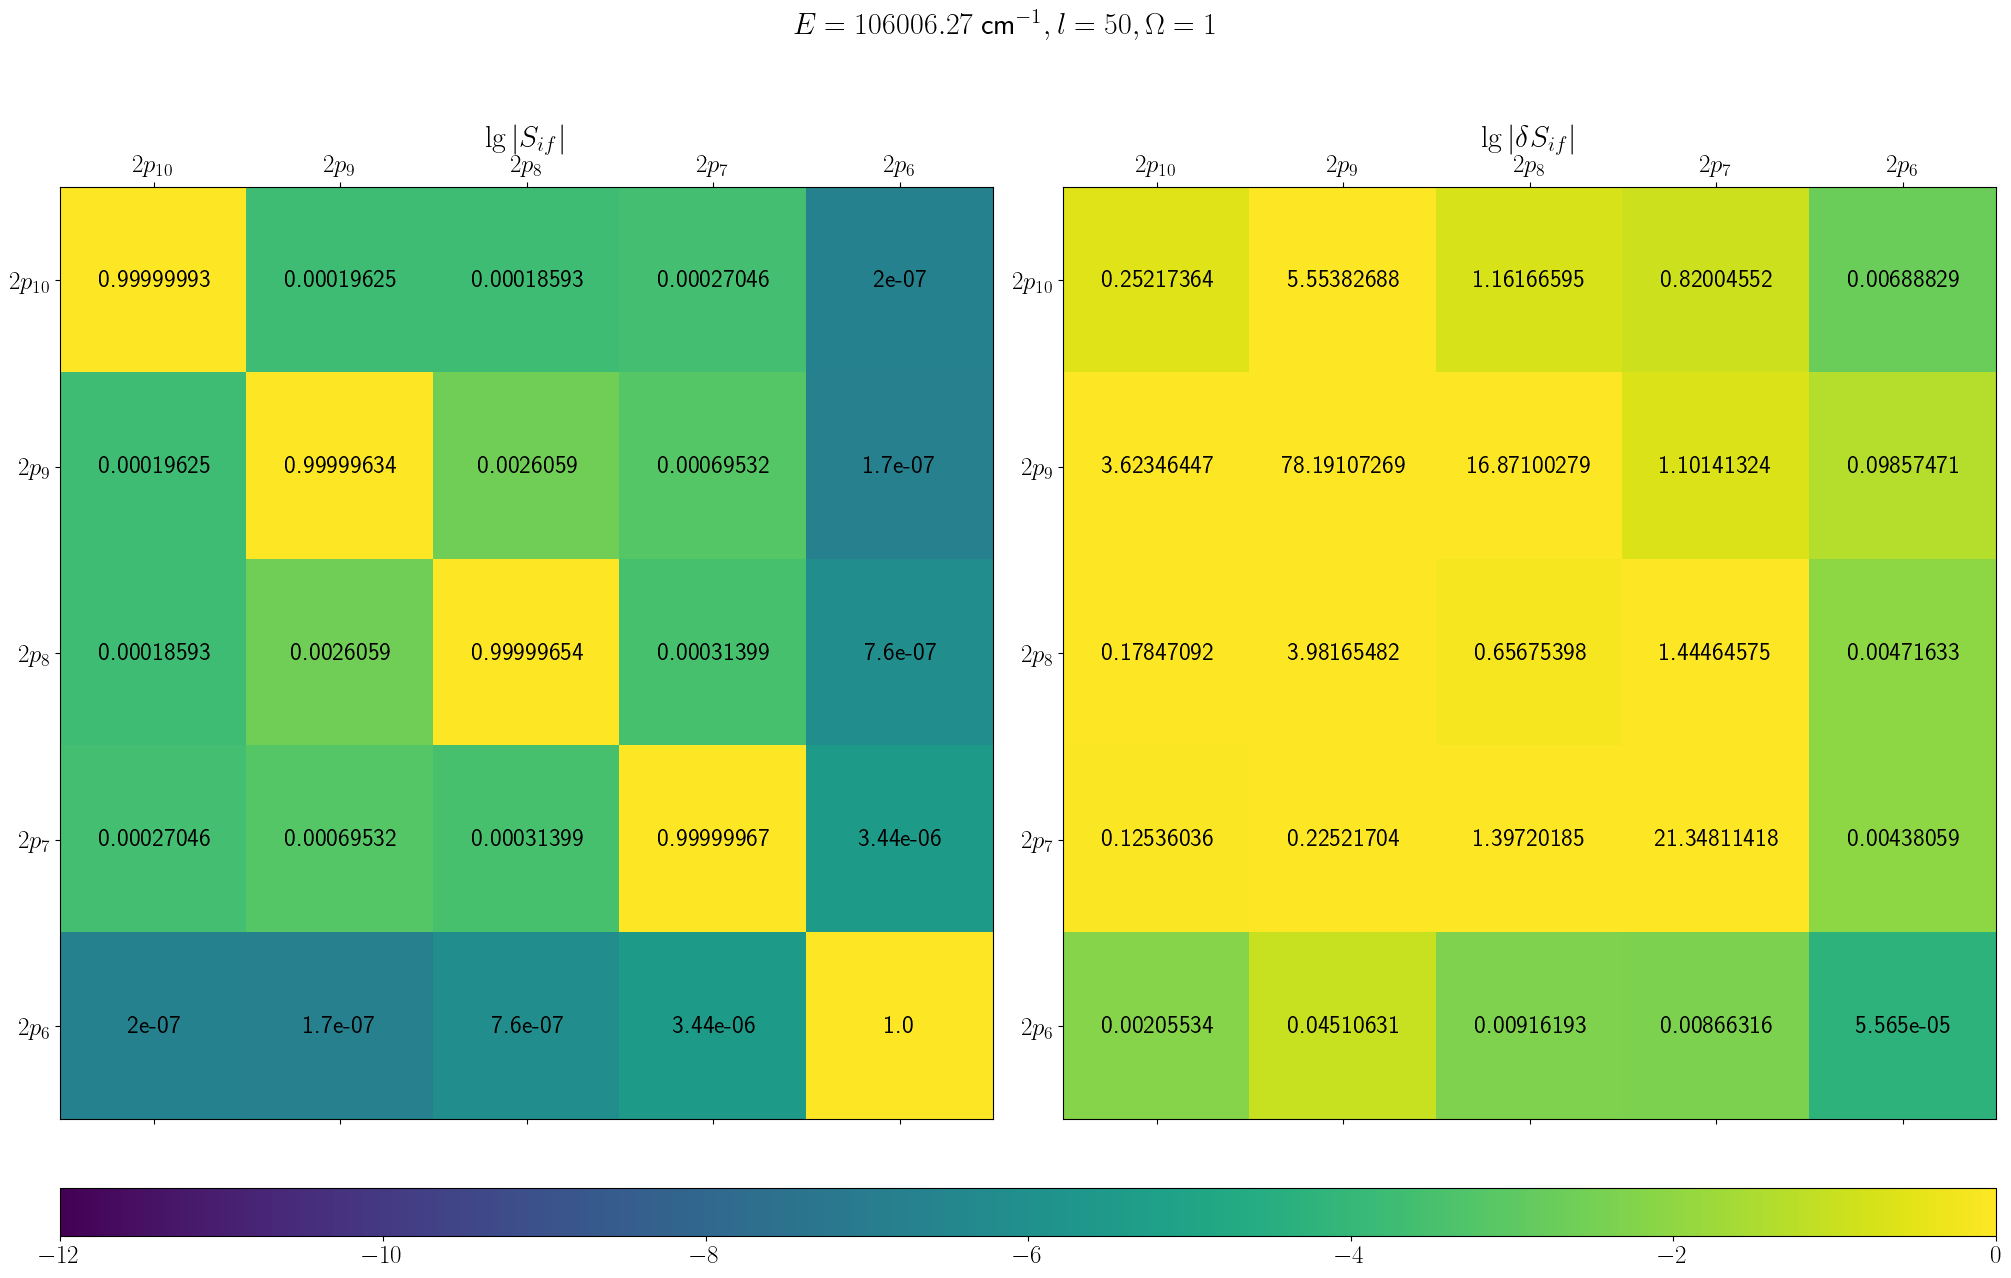

: 

: 

In [ ]:
from funcs import labels
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 18

p1_labels = [f'${l[:2]}_{{{l[2:]}}}$' for l in labels['p']['1']][:nt]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12.6), constrained_layout=True)

im1 = ax1.matshow(np.log10(np.abs(smat)), vmin=-12, vmax=0)
ax1.set_title(f'$\\lg |S_{{if}}|$')
ax1.set_xticklabels(['']+p1_labels)
ax1.set_yticklabels(['']+p1_labels)
for i in range(nt):
    for j in range(nt):
        ax1.text(i, j, str(np.round(np.abs(smat[i,j]), decimals=8)), va='center', ha='center')

im2 = ax2.matshow(np.log10(np.abs(dsmat)), vmin=-12, vmax=0)
ax2.set_title(f'$\\lg |\\delta S_{{if}}|$')
ax2.set_xticklabels(['']+p1_labels)
ax2.set_yticklabels(['']+p1_labels)
for i in range(nt):
    for j in range(nt):
        ax2.text(i, j, str(np.round(np.abs(dsmat[i,j]), decimals=8)), va='center', ha='center')

fig.suptitle(f'$E={np.real(es*4.637+emin)}$ cm$^{{-1}}, l={l}, \\Omega=1$')

cbar = fig.colorbar(im1, ax=[ax1, ax2], orientation='horizontal', shrink=1, aspect=40, pad=0.05)

plt.show()


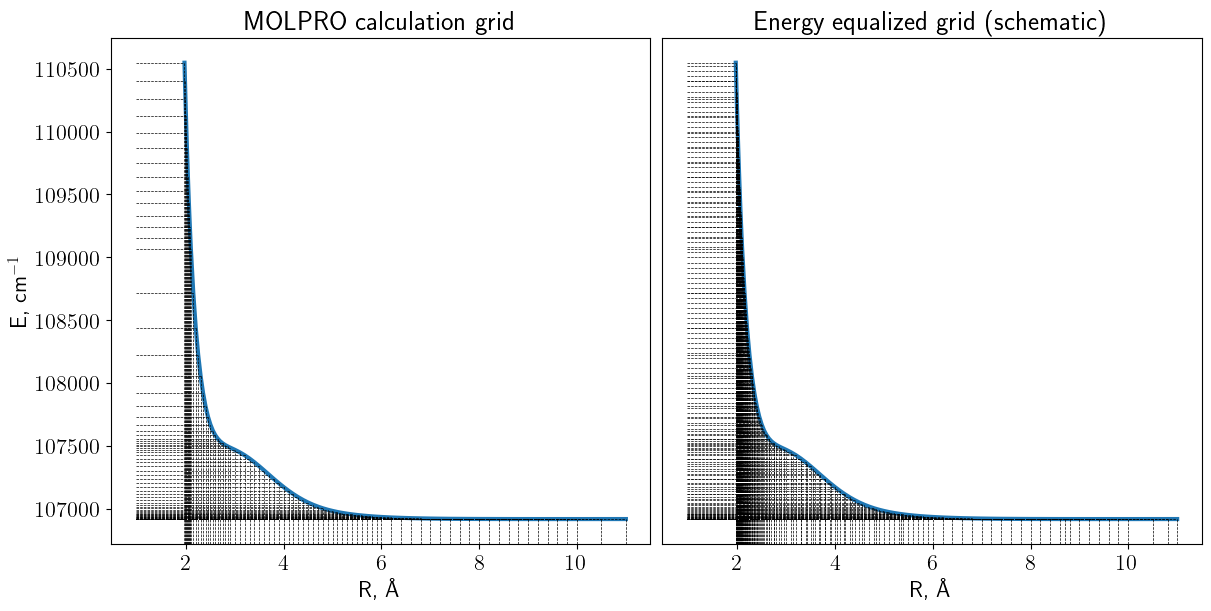

In [8]:
numstate = 3
curve = CubicSpline(r, np.real(hls[:,numstate, numstate]))

de = np.round(np.mean(np.abs(np.diff(np.real(hls[:,numstate, numstate])))), decimals=-1)
egrid_plot = np.arange(np.real(hls[-1,numstate, numstate]), np.real(hls[0,numstate, numstate])+de, de)
grid_plot = [x for x in r]
for i in range(n):
    for e in egrid_plot:
        roots = curve.solve(e)
        for x in roots:
            if x >= r[0] and x <= r[-1]:
                grid_plot.append(x)
newr = np.unique(np.sort(np.array(grid_plot)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

ax1.plot(r, np.real(hls[:,numstate, numstate]),lw=3)
for i in range(len(r)):
    ax1.plot([r[i], r[i]], [np.real(hls[-1,numstate, numstate])-200, np.real(curve(r[i]))], color='black', lw=0.5, linestyle='--')
    ax1.plot([r[0]-1, r[i]], [np.real(curve(r[i])), np.real(curve(r[i]))], color='black', lw=0.5, linestyle='--')
# ax1.xlim(1.5,11)
ax1.set_ylim(np.real(hls[-1,numstate, numstate])-200, np.real(hls[0,numstate, numstate])+200)
ax1.set_xlabel('R, \\AA')
ax1.set_ylabel('E, cm${}^{-1}$')
ax1.set_title(f'MOLPRO calculation grid')

ax2.plot(r, np.real(hls[:,numstate, numstate]),lw=3)
for i in range(len(newr)):
    ax2.plot([newr[i], newr[i]], [np.real(hls[-1,numstate, numstate])-200, np.real(curve(newr[i]))], color='black', lw=0.5, linestyle='--')
    ax2.plot([newr[0]-1, newr[i]], [np.real(curve(newr[i])), np.real(curve(newr[i]))], color='black', lw=0.5, linestyle='--')
# ax2.xlim(1.5,11.8)
ax2.get_yaxis().set_visible(False)
ax2.set_ylim(np.real(hls[-1,numstate, numstate])-200, np.real(hls[0,numstate, numstate])+200)
ax2.set_xlabel('R, \\AA')
ax2.set_title(f'Energy equalized grid (schematic)')
# ax2.ylabel('E, cm${}^{-1}$')

plt.show()